# Card Duels Project
The project focuses on developing, training and evaluating a DQN in an environment with large descrete combinatorial action space and partial observability (POMDP), like a card game.
The project is composed by three main phases:
- exposing the generic game rules and mechanics;
- the construction of the environment;
- the construction of the agents;
- the training phase in different settings;
- evaluation of diagnostics and comparison.

Before starting the actual implemetation of the model we have to define the rules of the game the model will play at. 

### The Game mechanics
The Card Game is a semplified version of a famous card game called "*Magic: the Gathering*".
In this game the two players challenge each other in a battle to the last Life Point (HP), each using their own deck of cards. Following are presented the main mechanics of the game.

- **Objective:** reduce the opponent's HP to zero.

- **The Deck:** each player has a fixed deck of *MAX_DECK* (default 20) cards. Every turn the player draw a card randomly without replacement from his deck.

- **The Hand:** each player can store in his hand a maximum number of cards *MAX_HAND* (default 5) hidden to the opponent. Every turn the player selects cards from his hand (select an action) into the board (visible to the opponent) and the battle between the board's cards begin.

- **The Cards:** Each card is identified by an *ID* and a *Name*, and it is defined by *Cost*, *ATK* (Attack) score, *DEF* (Defense) score, and any special effects (Draw, Heal, Burn, Wipe). Cards with DEF == 0 are considered spell cards, else they are considered creature cards. Example of cards:
    - { "id": "11", "name": "Wooden Barricade", "cost": 2, "atk": 0, "def": 6, "m_draw": 0, "m_burn": 0, "m_heal": 0, "m_wipe": 0 }
    - { "id": "32", "name": "Vampiric Drain", "cost": 4, "atk": 0, "def": 0, "m_draw": 0, "m_burn": 3, "m_heal": 3, "m_wipe": 0 }

- **Mana mechanic:** The game uses a limited resource system (Hearthstone style). Maximum mana increases by 1 each turn (up to a cap, e.g. 10) and is fully replenished at the beginning of the turn. The sum of the costs of the cards played in a turn must be $\le$ the current mana.

- **Basic Turn structure:**
    1. **_Restore phase_** -> The player draws a single card up to the maximum hand limit *MAX_HAND*.
    2. **_Action phase_** -> The player selects a subset of cards from their hand to deploy simultaneously. With mana constraint: $\sum_{c \in \text{action}}^{}{c_{Cost}} \le \text{MAX\_MANA}$.
    3. **_Resolution phase_** -> Firstly, the effects for each selected (deployed) cards are resolved. Then, the sum of the ATK (Attack) of the deployed and the "already on attacker's board" cards, and the sum of the DEF (Defense) of the cards on the defender's board are calculated. If $\sum ATK > \sum DEF$, the difference is subtracted from the defender's HP. Defensive cards that absorb damage are destroyed starting from the cards with max DEF score to the weakest ('Highest DEF First'); surviving cards remain on the board for subsequent turns. Like in the original Magic game, the card damage is NOT persistent, so at the end of the turn, the card that absorbed the remaining atk damage without dying regains the original defense score.

##### Special card effects
- **Card Draw:** Allows draw _m_draw_ cards from the deck. Generates "Card Advantage". The DQN must understand that spending mana to draw cards does not provide an immediate advantage on the board, but increases the likelihood of finding lethal combinations in subsequent turns.

- **Burn:** Inflicts _m_burn_ points of direct damage to the opponent's HP, ignoring Defense cards on the board.

- **Heal:** Restores _m_heal_ HP to the current player. Excellent for countering aggressive opponents, forcing the opponent to weigh the marginal utility of survival.

- **Board Wipe:** Destroys _m_wipe_ random cards on the opponent's board before damage is calculated. This introduces massive swings in the state of the game.

##### Fatigue damage
What happens if the deck runs out? The **Fatigue Damage** mechanic is applied.
This is to guarantee a finite horizon (the episode must eventually end to compute the sparse reward) to the POMDP and because the network needs a mathematical reason _not_ to blindly spam card-drawing effects.
When a player enters the _Restore Phase_ or uses a card with an $m_{draw}$ effect, and their deck is empty, the following should happen:
- **The Fatigue Rule:** For every card a player is forced to draw from an empty deck, they immediately take **cumulative unblockable damage**.
- **The Progression:** The first time they draw from an empty deck, they take 1 damage. The second time, 2 damage. The third time, 3 damage, and so on.


To manage easily the set of available cards and the construction of the deck, a _.json_ file is used in the path "./data/cards.json", to load the card pool into the environment class. Then a list of indices _DECK_ is used to build the deck for each player (in our settings the two player have always the same 20-cards-deck for semplicity).

In [1]:
from env.cards import load_card_pool

cards_path = "./data/cards.json" # Where to find the cards set.
CARD_POOL = load_card_pool(cards_path) # Card pool is a dictionary of card ids to card data 'dict[str, Card]'.

# Build the deck using card ids. 20 cards deck.
DECK = [
        "01", "02", "20", "33",         # 1-Cost
        "03", "11", "17",               # 2-Cost
        "05", "14", "16", "21", "27",   # 3-Cost
        "07", "12",                     # 4-Cost
        "08", "34",                     # 5-Cost
        "13",                           # 6-Cost
        "09", "29",                     # 7-Cost
        "38"                            # 8-Cost
    ]

# Game constants
MAX_HAND = 5 # Maximum number of cards in hand.
MAX_HP = 40 # Maximum health points.
MANA_LIMIT = 10 # Maximum mana points.
MAX_BOARD = 7 # Maximum number of cards on board.

### Environment Implementation
The basic data structures of the game'state are the two classes _Card_ and _Deck_, respectively managing the card and the deck entities.

##### Card (./env/cards.py)
The Card class acts as the atomic unit of the game state. It stores string attributes (id, name) and all the statistics of a card entity.
Essentially, it has only one critical function: _to_vector()_. The _to_vector()_ method projects the card's mechanical attributes into a 7-dimensional feature space, generating a vector $x \in \mathbb{R}^7$:$$x = [\text{Cost}, \text{ATK}, \text{DEF}, \text{m\_draw}, \text{m\_burn}, \text{m\_heal}, \text{m\_wipe}].$$

##### Deck (./env/cards.py)
The Deck class manages the primary source of transition stochasticity in the POMDP, the randomic draw from a shuffeled deck (draw(self) -> Card | None).
The _reset()_ method ensures that every episode begins with an independent and identically distributed shuffle of the deck.

##### Player (./env/engine.py)
The Player class is the central data structure responsible for maintaining the state variables and memory buffers for an individual agent during the episode.
The Player has a Deck, HP, mana, hand cards, board cards, history, and a fatigue counter. It manages all those state variables.
- **Memory Buffers**: The class encapsulates four distinct spatial zones: the deck (remaining potential), the hand (available actions), the board (deployed persistent units), and the history (the graveyard for destroyed cards or resolved spells). 
- **State Transition**: The *draw_card()* method executes the drawing mechanic and enforces two critical game theory rules: 
    - Hand Limit Overflow: If the agent draws a card while their hand is full, the card is immediately discarded to the history buffer.
    - Fatigue Damage: If the deck is empty, the agent increments a fatigue_counter and takes compounding cumulative damage (hp -= fatigue_counter). This guarantees a finite Markov episode horizon.

##### GameState (./env/engine.py)
The GameState class acts as the deterministic transition engine of the MDP. It orchestrates the flow of alternating turns, applies the mathematical rules of combat, and evaluates terminal conditions.
Two methods are noteworthy:
- ***start_turn() (Restore Phase)***: This method initializes the physical environment for the active player immediately before they select an action:
    1. *Resource Management*: Increments the player's mana capacity and fully replenishes their available mana pool.
    2. *State Updates*: Forces the player to draw a card, which implicitly evaluates the fatigue penalty if the deck is empty.
    3. *Early Termination Check*: Evaluates _game_over_check() immediately, as lethal fatigue damage taken during the draw phase can end the episode before an action is even processed.

- ***play_turn() (Action & Resolution Phase)***: This is the core execution block where the binary action vector generated by the DQN interacts with the physical rules of the game:
    1. *Action Execution*: Iterates backward through the binary action array. This backward loop is a critical computer science safety mechanism: it guarantees that pop() operations on the hand list do not dynamically shift the memory indices of the remaining cards, preserving perfect structural alignment with the neural network's action mask.
    2. *MDP Constraint Validation*: validates the total mana cost and array bounds. It raises explicit custom errors if the action exceeds the limits, preventing silent failures.
    3. *Combat Resolution* (_resolve_combat): resolves magic effects (Wipe, Burn, Heal, Draw) and aggregates the total attack power. Executes the "Highest DEF (Defense) First" deterministic algorithm: it sorts the defending board by defense and sequentially subtracts the aggregated ATK (Attack). Calculates leftover "face" damage to the opponent's HP and deploys any surviving units to the active board spaces.
    4. *State Transition*: Evaluates the final terminal win/loss conditions and swaps the active_p_idx pointer, completing the step and handing control to the opponent.


##### Action & State encoding
Before continuing with the actual gymnasium environment wrapper implementation, it is important to explain how the environment and the agents interact through the observation and the action data structures. So essentially how actions and states are encoded.

***Action encoding***

The action space is discrete and combinatorial. Considering $\mathbf{H}$ as the hand maximum card limit, the agent must chooses a binary vector $a \in \{0, 1\}^H$ (a H-length vector of $0$ and $1$). The cardinality of the action space is the power set: $\vert{}\mathcal{A}\vert{} = 2^H$.

Standard DQN and the _gymnasium.spaces.Discrete_ API are architected to output a single scalar integer representing the index of the chosen action. For $H = 5$, the neural network's final classification layer outputs a single integer $a \in [0, 31]$. Because the game engine's _play_turn()_ method cannot process a raw integer like 20, the environment must decode this mathematical index back into its physical representation using 'format(action, f'0{self.max_hand}b')'; this dynamically converts the base-10 integer into a base-2 (binary) string, strictly padded with leading zeros to guarantee it is exactly max_hand characters long (e.g., integer 20 becomes string "10100"). This translation bridges the gap between the discrete scalar output of the neural network and the multi-action physical mechanics of the environment. 

Since we are playing also with the mana constraints imposed by the environment, we must proactively prevent the neural network from exploring structurally impossible card combinations, such as attempting to spend 15 mana when only 5 is available. We do that enforcing absolute MDP constraints directly into the forward pass using **Action Masking**.
This mask is passed to the agent during the select_action phase. Before the network applies its $\epsilon$-greedy policy or takes the argmax, it multiplies the invalid Q-values by $-\infty$. This mathematically forces the probability of selecting an illegal action to exactly zero, allowing the optimizer to dedicate 100% of its gradient updates to strategic decision-making rather than rule memorization.

***State encoding***

The observation space is defined as a spaces.Dict (dictionary), where for each key string (like "self_stats") corresponds a category of game state informations encoded as fixed length  vectors reflecting the analogy with a real game setting, where each player can not access to the opponent's hand cards or to next draw card (for example). This kind of implementation consent to achieve structural modularity. The complete state observation is composed by:
- **self_stats**: [self HP, self mana, self max_mana, number of cards in deck],
- **opp_stats:** [opp HP, n cards in opp hand, number of cards in opp deck],
- **self_hand:** $\mathbb{R}^{\text{max\_hand} \times 7}$ matrix containing normalized features for each self hand card,
- **self_board**: $\mathbb{R}^{\text{max\_baord} \times 7}$ matrix containing normalized features for each self board card,
- **opp_board:** $\mathbb{R}^{\text{max\_baord} \times 7}$ matrix containing normalized features for each opponent board card,
- **history_opp**: $\mathbb{R}^{\text{max\_deck} \times 7}$ matrix containing normalized features for each card in the opponent graveyard,
- **deck_stats_self**: $\mathbb{R}^{\text{max\_deck} \times 7}$ matrix containing normalized features for each self deck card.


To prevent gradient instability (due to different statistics ranges), the environment applies deterministic Min-Max scaling directly inside the _get_obs() method. Every matrix and vector is divided by its maximum theoretical bounds. This mathematical transformation bounds all observation tensors strictly within the $[-1, 1]$ range.

***Reward Function***

The **reward function** is a  *terminal reward function* because it is computed only at the end of a single game (single episode):
- $+1 \rightarrow$ ***WIN***
- $-1 \rightarrow$ ***LOSE***
- $0 \rightarrow$ ***DRAW*** (simultaneous destruction)

##### CardDuelsEnv (./env/environment.py)
The CardDuelsEnv inherit from the gym.Env wrapper class and serves as bridge between the custom "GameState" rules engine and the RL agents. Relevant methods are:

- Initialization (__init__): declares the boundaries of the environment. It defines the action space as a spaces.Discrete scalar of size $2^H$ and the observation space as a highly modular spaces.Dict containing bounded continuous tensors.

- Episode Initialization (reset): Resets the MDP to state $t=0$. It instantiates fresh Deck and Player objects, shuffles the card pools, draws the initial starting hands, and triggers the first restore phase.

- State Transitions (step): It decodes the neural network's integer output into a binary array and advances the physical engine (play_turn). It evaluates the terminal conditions and computes the sparse zero-sum reward ($+1.0$ for a win, $-1.0$ for a loss, $0.0$ for a draw), returning the tuple: (observation, reward, terminated, truncated, info).

- Observation Formatting (_get_obs): Extracts the raw OOP objects from the engine and translates them into tensors. It sorts the hand and board arrays before translation to enforce Permutation Invariance (reducing the state-space complexity) and applies strict Min-Max Normalization to stabilize the gradient descent.

- Constraint Enforcement (_get_info): Pre-computes the physical legality of all possible combinatorial actions given the current mana and hand bounds, outputting the action_mask utilized by the DQN to bypass illegal branches of the decision tree.

### Agents implementation

##### Heuristic agent

##### DQN agent

In [5]:
# DQN Agent training hyperparameters

LEARNING_RATE_START = 1e-3 # Learning rate for the optimizer.
LEARNING_RATE_MIN = 1e-5 # Minimum learning rate for the optimizer.

GAMMA = 0.99 # Discount factor for future rewards.

EPSILON_START = 1.0 # Initial exploration rate.
EPSILON_MIN = 0.05 # Minimum exploration rate.
EPSILON_DECAY = 0.99975 # Decay rate for exploration.

BUFFER_CAPACITY = 100_000 # Capacity of the replay buffer.
BATCH_SIZE = 128 # Batch size for training.
MIN_BUFFER_SIZE = 5_000 # Minimum number of experiences in the buffer before training.

TRAIN_FREQUENCY = 4 # Number of steps between training updates.
TARGET_SYNC_EVERY = 500 // TRAIN_FREQUENCY # 125 Number of updates (gradient steps) before syncing the target network.

# Heuristic Opponent hyperparameters
TEMPERATURE = 1.0 # Temperature parameter for the heuristic opponent's decision-making.

### Training

##### Partial Observability Study: Training against heuristic agent with different observation settings

In [6]:
import os
from typing import Any

from agents.dqn_agent import DQNAgent
from agents.heuristic_agent import HeuristicOpponent
from env.environment import CardDuelsEnv
from scripts.train import (
    load_latest_checkpoint,
    train_against_heuristic,
    train_self_play,
)
from utils.plot_diagnostics import (
    plot_ablation_study,
    plot_hyperparameter_variance,
    plot_training_diagnostics,
)

# Training hyperparameters
NUM_EPISODES = 20000 # Number of episodes to train the agent.
MAX_STEPS = 200 # Maximum number of steps per episode.
LOG_EVERY = 250 # Log training progress every LOG_EVERY episodes.
SEED = 42 # Random seed for reproducibility.


In [ ]:
# Train the model with heuristic agent

ablation_configs = {
    "Omniscient MDP": ["self_stats", "opp_stats", "self_hand", "opp_hand", "self_board", "opp_board", "history_opp", "history_self", "deck_stats_self"],
    "Full POMDP": ["self_stats", "opp_stats", "self_hand", "self_board", "opp_board", "history_opp", "history_self", "deck_stats_self"],
    "No Deck Stats": ["self_stats", "opp_stats", "self_hand", "self_board", "opp_board", "history_opp"],
    "Minimal State": ["self_stats", "opp_stats", "self_hand", "self_board", "opp_board"]
}

histories: dict[str, Any] = {}

heuristic_agent = HeuristicOpponent(
            max_hp=MAX_HP, 
            max_hand=MAX_HAND, 
            max_board=MAX_BOARD, 
            temperature=TEMPERATURE
        )

for label, obs_features in ablation_configs.items():
    print(f"--- Starting Training for Config: {label} ---")

    env = CardDuelsEnv(
            card_pool=CARD_POOL, 
            deck_list_p1=DECK,
            deck_list_p2=DECK,
            max_hand=MAX_HAND,
            max_board=MAX_BOARD,
            max_hp=MAX_HP,
            mana_limit=MANA_LIMIT,
            total_unique_cards=len(CARD_POOL),
            obs_features=obs_features
        )

    agent = DQNAgent(
            observation_space=env.observation_space,
            action_space=env.action_space,
            total_episodes=NUM_EPISODES,
            lr_start=LEARNING_RATE_START,
            lr_min=LEARNING_RATE_MIN,
            gamma=GAMMA,
            epsilon_start=EPSILON_START,
            epsilon_min=EPSILON_MIN,
            epsilon_decay=EPSILON_DECAY,
            buffer_capacity=BUFFER_CAPACITY,
            batch_size=BATCH_SIZE,
            min_buffer_size=MIN_BUFFER_SIZE,
            target_sync_every=TARGET_SYNC_EVERY
        )

    heuristic_agent.temperature = TEMPERATURE

    safe_folder_name = label.replace(" ", "_").lower()
    history = train_against_heuristic(
        agent=agent,
        heuristic_agent=heuristic_agent,
        env=env,
        episodes=NUM_EPISODES,
        max_steps=MAX_STEPS,
        train_freq=TRAIN_FREQUENCY,
        log_every=LOG_EVERY,
        save_dir=f"./checkpoints/heuristic_ablation/{safe_folder_name}",
        seed=SEED
    )

    histories[label] = history

plot_ablation_study(histories)

--- Starting Training for Config: Omniscient MDP ---


Ep 00250 | Eval Win: 0.65 | Eval Ret: +0.65 ± 0.48 | Eps: 0.939 | |w|: 0.00 | Avg Len: 18.1 | Avg Deck: 3.9 | Saved: dqn_heuristic_00250.pth
Ep 00500 | Eval Win: 0.60 | Eval Ret: +0.60 ± 0.49 | Eps: 0.882 | |w|: 0.00 | Avg Len: 18.8 | Avg Deck: 3.4 | Saved: dqn_heuristic_00500.pth
Ep 00750 | Eval Win: 0.75 | Eval Ret: +0.75 ± 0.43 | Eps: 0.829 | |w|: 72.28 | Avg Len: 18.2 | Avg Deck: 3.8 | Saved: dqn_heuristic_00750.pth
Ep 01000 | Eval Win: 0.60 | Eval Ret: +0.60 ± 0.49 | Eps: 0.779 | |w|: 75.97 | Avg Len: 18.5 | Avg Deck: 3.5 | Saved: dqn_heuristic_01000.pth
Ep 01250 | Eval Win: 0.55 | Eval Ret: +0.45 ± 0.67 | Eps: 0.732 | |w|: 78.73 | Avg Len: 19.4 | Avg Deck: 3.0 | Saved: dqn_heuristic_01250.pth
Ep 01500 | Eval Win: 0.65 | Eval Ret: +0.65 ± 0.48 | Eps: 0.687 | |w|: 80.75 | Avg Len: 19.1 | Avg Deck: 3.1 | Saved: dqn_heuristic_01500.pth
Ep 01750 | Eval Win: 0.45 | Eval Ret: +0.40 ± 0.58 | Eps: 0.646 | |w|: 82.63 | Avg Len: 19.1 | Avg Deck: 3.2 | Saved: dqn_heuristic_01750.pth


##### Training against heuristic agent with different Replay Buffer sizes and target network update frequency


--- Starting Ablation Run: Buf_10k_Sync_100 ---


Ep 00050 | Eval Win: 0.75 | Eval Ret: +0.75 ± 0.43 | Eps: 0.988 | |w|: 0.00 | Avg Len: 18.3 | Avg Deck: 3.6 | Saved: dqn_heuristic_00050.pth
Ep 00100 | Eval Win: 0.65 | Eval Ret: +0.60 ± 0.58 | Eps: 0.975 | |w|: 0.00 | Avg Len: 18.0 | Avg Deck: 3.6 | Saved: dqn_heuristic_00100.pth
Ep 00150 | Eval Win: 0.70 | Eval Ret: +0.70 ± 0.46 | Eps: 0.963 | |w|: 66.75 | Avg Len: 17.5 | Avg Deck: 4.2 | Saved: dqn_heuristic_00150.pth
Ep 00200 | Eval Win: 0.60 | Eval Ret: +0.55 ± 0.59 | Eps: 0.951 | |w|: 68.43 | Avg Len: 17.3 | Avg Deck: 4.4 | Saved: dqn_heuristic_00200.pth



--- Starting Ablation Run: Buf_50k_Sync_500 ---


Ep 00050 | Eval Win: 0.65 | Eval Ret: +0.65 ± 0.48 | Eps: 0.988 | |w|: 0.00 | Avg Len: 19.0 | Avg Deck: 3.1 | Saved: dqn_heuristic_00050.pth
Ep 00100 | Eval Win: 0.65 | Eval Ret: +0.65 ± 0.48 | Eps: 0.975 | |w|: 0.00 | Avg Len: 17.2 | Avg Deck: 4.3 | Saved: dqn_heuristic_00100.pth
Ep 00150 | Eval Win: 0.55 | Eval Ret: +0.55 ± 0.50 | Eps: 0.963 | |w|: 66.01 | Avg Len: 18.6 | Avg Deck: 3.5 | Saved: dqn_heuristic_00150.pth
Ep 00200 | Eval Win: 0.70 | Eval Ret: +0.70 ± 0.46 | Eps: 0.951 | |w|: 66.84 | Avg Len: 17.7 | Avg Deck: 4.0 | Saved: dqn_heuristic_00200.pth



--- Starting Ablation Run: Buf_100k_Sync_1000 ---


Ep 00050 | Eval Win: 0.35 | Eval Ret: +0.35 ± 0.48 | Eps: 0.988 | |w|: 0.00 | Avg Len: 18.3 | Avg Deck: 3.8 | Saved: dqn_heuristic_00050.pth
Ep 00100 | Eval Win: 0.40 | Eval Ret: +0.40 ± 0.49 | Eps: 0.975 | |w|: 0.00 | Avg Len: 18.5 | Avg Deck: 3.5 | Saved: dqn_heuristic_00100.pth
Ep 00150 | Eval Win: 0.30 | Eval Ret: +0.30 ± 0.46 | Eps: 0.963 | |w|: 66.26 | Avg Len: 18.1 | Avg Deck: 3.8 | Saved: dqn_heuristic_00150.pth
Ep 00200 | Eval Win: 0.40 | Eval Ret: +0.40 ± 0.49 | Eps: 0.951 | |w|: 67.25 | Avg Len: 17.5 | Avg Deck: 4.2 | Saved: dqn_heuristic_00200.pth



--- Starting Ablation Run: Buf_500k_Sync_5000 ---


Ep 00050 | Eval Win: 0.35 | Eval Ret: +0.35 ± 0.48 | Eps: 0.988 | |w|: 0.00 | Avg Len: 17.9 | Avg Deck: 3.8 | Saved: dqn_heuristic_00050.pth
Ep 00100 | Eval Win: 0.35 | Eval Ret: +0.35 ± 0.48 | Eps: 0.975 | |w|: 0.00 | Avg Len: 18.9 | Avg Deck: 3.6 | Saved: dqn_heuristic_00100.pth
Ep 00150 | Eval Win: 0.55 | Eval Ret: +0.55 ± 0.50 | Eps: 0.963 | |w|: 66.38 | Avg Len: 18.5 | Avg Deck: 4.0 | Saved: dqn_heuristic_00150.pth
Ep 00200 | Eval Win: 0.30 | Eval Ret: +0.30 ± 0.46 | Eps: 0.951 | |w|: 67.10 | Avg Len: 18.3 | Avg Deck: 4.2 | Saved: dqn_heuristic_00200.pth


Variance analysis plot saved successfully to: ./plots/variance_analysis.png


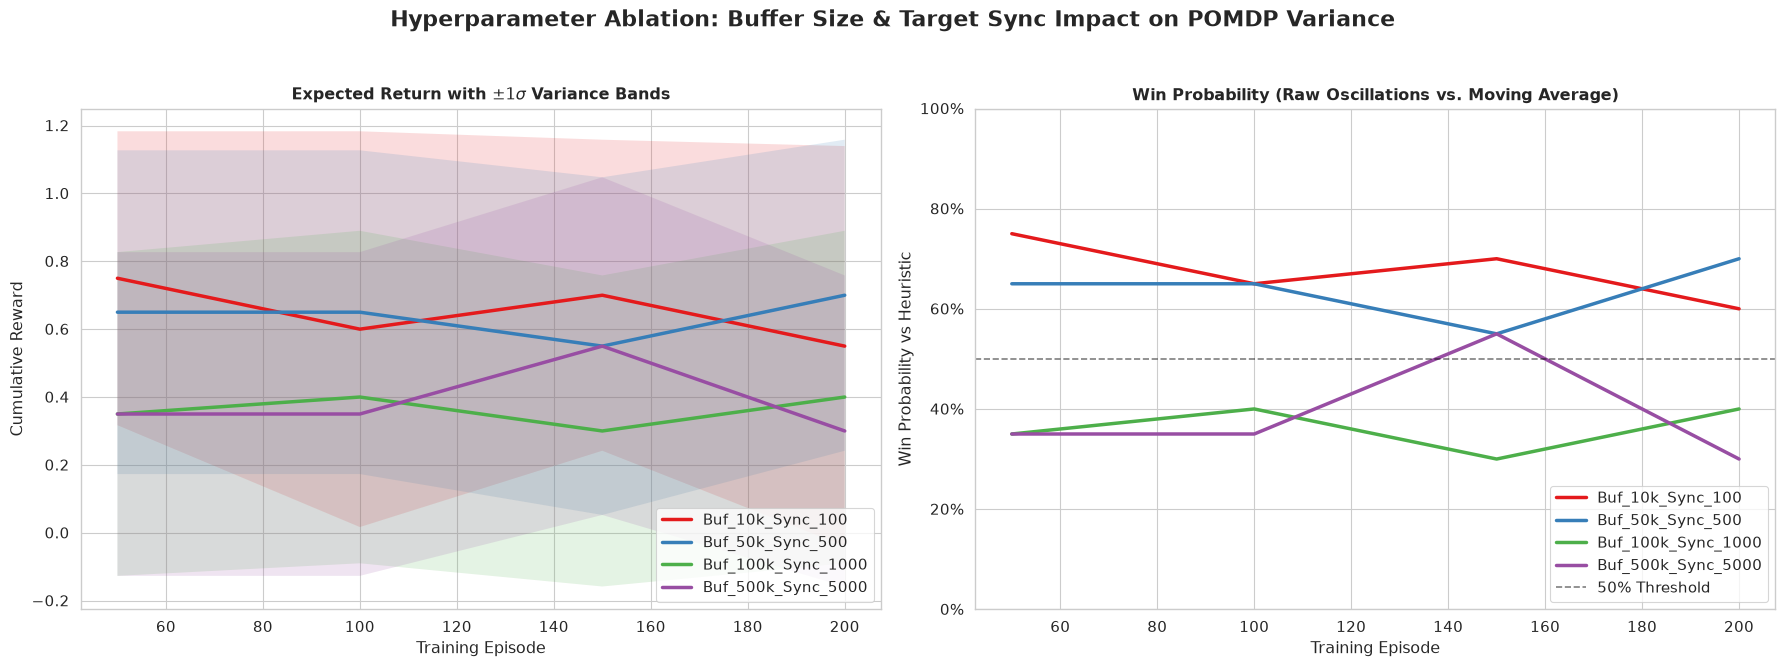

In [ ]:

hyperparameter_pairs = [
    (10_000, 100),   
    (50_000, 500),   
    (100_000, 1000), 
    (500_000, 5000)  
]

standard_features = [
    "self_stats", "opp_stats", "self_hand", "self_board", 
    "opp_board", "history_opp", "history_self", "deck_stats_self"
]

hyperparam_histories: dict[str, Any] = {}

heuristic_agent = HeuristicOpponent(
    max_hp=MAX_HP,
    max_hand=MAX_HAND,
    max_board=MAX_BOARD,
    temperature=TEMPERATURE
)

for buffer_size, sync_freq in hyperparameter_pairs:
    
    label = f"Buf_{buffer_size // 1000}k_Sync_{sync_freq}"
    print(f"\n--- Starting Ablation Run: {label} ---")
    
    env = CardDuelsEnv(
        card_pool=CARD_POOL, 
        deck_list_p1=DECK,
        deck_list_p2=DECK,
        max_hand=MAX_HAND,
        max_board=MAX_BOARD,
        max_hp=MAX_HP,
        mana_limit=MANA_LIMIT,
        total_unique_cards=len(CARD_POOL),
        obs_features=standard_features,
    )

    # Initialize agent with the specific ablated hyperparameters
    agent = DQNAgent(
        observation_space=env.observation_space,
        action_space=env.action_space,
        buffer_capacity=buffer_size,      # ABLATED PARAMETER
        target_sync_every=sync_freq,      # ABLATED PARAMETER
        total_episodes=NUM_EPISODES,
        lr_start=LEARNING_RATE_START,
        lr_min=LEARNING_RATE_MIN,
        gamma=GAMMA,
        epsilon_start=EPSILON_START,
        epsilon_min=EPSILON_MIN,
        epsilon_decay=EPSILON_DECAY,
        batch_size=BATCH_SIZE,
        min_buffer_size=MIN_BUFFER_SIZE
    )

    heuristic_agent.temperature = TEMPERATURE
    
    safe_folder_name = f"pomdp_variance_buf{buffer_size}_sync{sync_freq}"
    
    history = train_against_heuristic(
        agent=agent,
        heuristic_agent=heuristic_agent,
        env=env,
        episodes=NUM_EPISODES,
        max_steps=MAX_STEPS,
        train_freq=TRAIN_FREQUENCY,
        log_every=LOG_EVERY,
        save_dir=os.path.join("./checkpoints/hyperparams/", safe_folder_name),
        seed=SEED
    )
    
    hyperparam_histories[label] = history

plot_hyperparameter_variance(hyperparam_histories)


##### Self-Play Training: Training using the same DQN model as player 1 and 2

Ep 00100 | Eval Win: 0.15 | Eval Ret: +0.15 ± 0.36 | Eps: 0.975 | |w|: 0.00 | Avg Len: 18.4 | Avg Deck: 3.4 | Saved: dqn_heuristic_00100.pth
Ep 00200 | Eval Win: 0.70 | Eval Ret: +0.70 ± 0.46 | Eps: 0.951 | |w|: 23.24 | Avg Len: 18.6 | Avg Deck: 3.8 | Saved: dqn_heuristic_00200.pth
Ep 00300 | Eval Win: 0.65 | Eval Ret: +0.65 ± 0.48 | Eps: 0.928 | |w|: 28.53 | Avg Len: 19.4 | Avg Deck: 3.1 | Saved: dqn_heuristic_00300.pth
Ep 00400 | Eval Win: 0.65 | Eval Ret: +0.60 ± 0.58 | Eps: 0.905 | |w|: 32.54 | Avg Len: 19.1 | Avg Deck: 3.1 | Saved: dqn_heuristic_00400.pth
Ep 00500 | Eval Win: 0.45 | Eval Ret: +0.40 ± 0.58 | Eps: 0.882 | |w|: 35.50 | Avg Len: 18.4 | Avg Deck: 3.6 | Saved: dqn_heuristic_00500.pth
Ep 00600 | Eval Win: 0.50 | Eval Ret: +0.45 ± 0.59 | Eps: 0.861 | |w|: 38.07 | Avg Len: 18.6 | Avg Deck: 3.6 | Saved: dqn_heuristic_00600.pth
Ep 00700 | Eval Win: 0.50 | Eval Ret: +0.50 ± 0.50 | Eps: 0.839 | |w|: 40.17 | Avg Len: 18.2 | Avg Deck: 3.9 | Saved: dqn_heuristic_00700.pth
Ep 0080

Diagnostics plot successfully saved to: ./plots/heuristic/dqn_diagnostics_grid.png


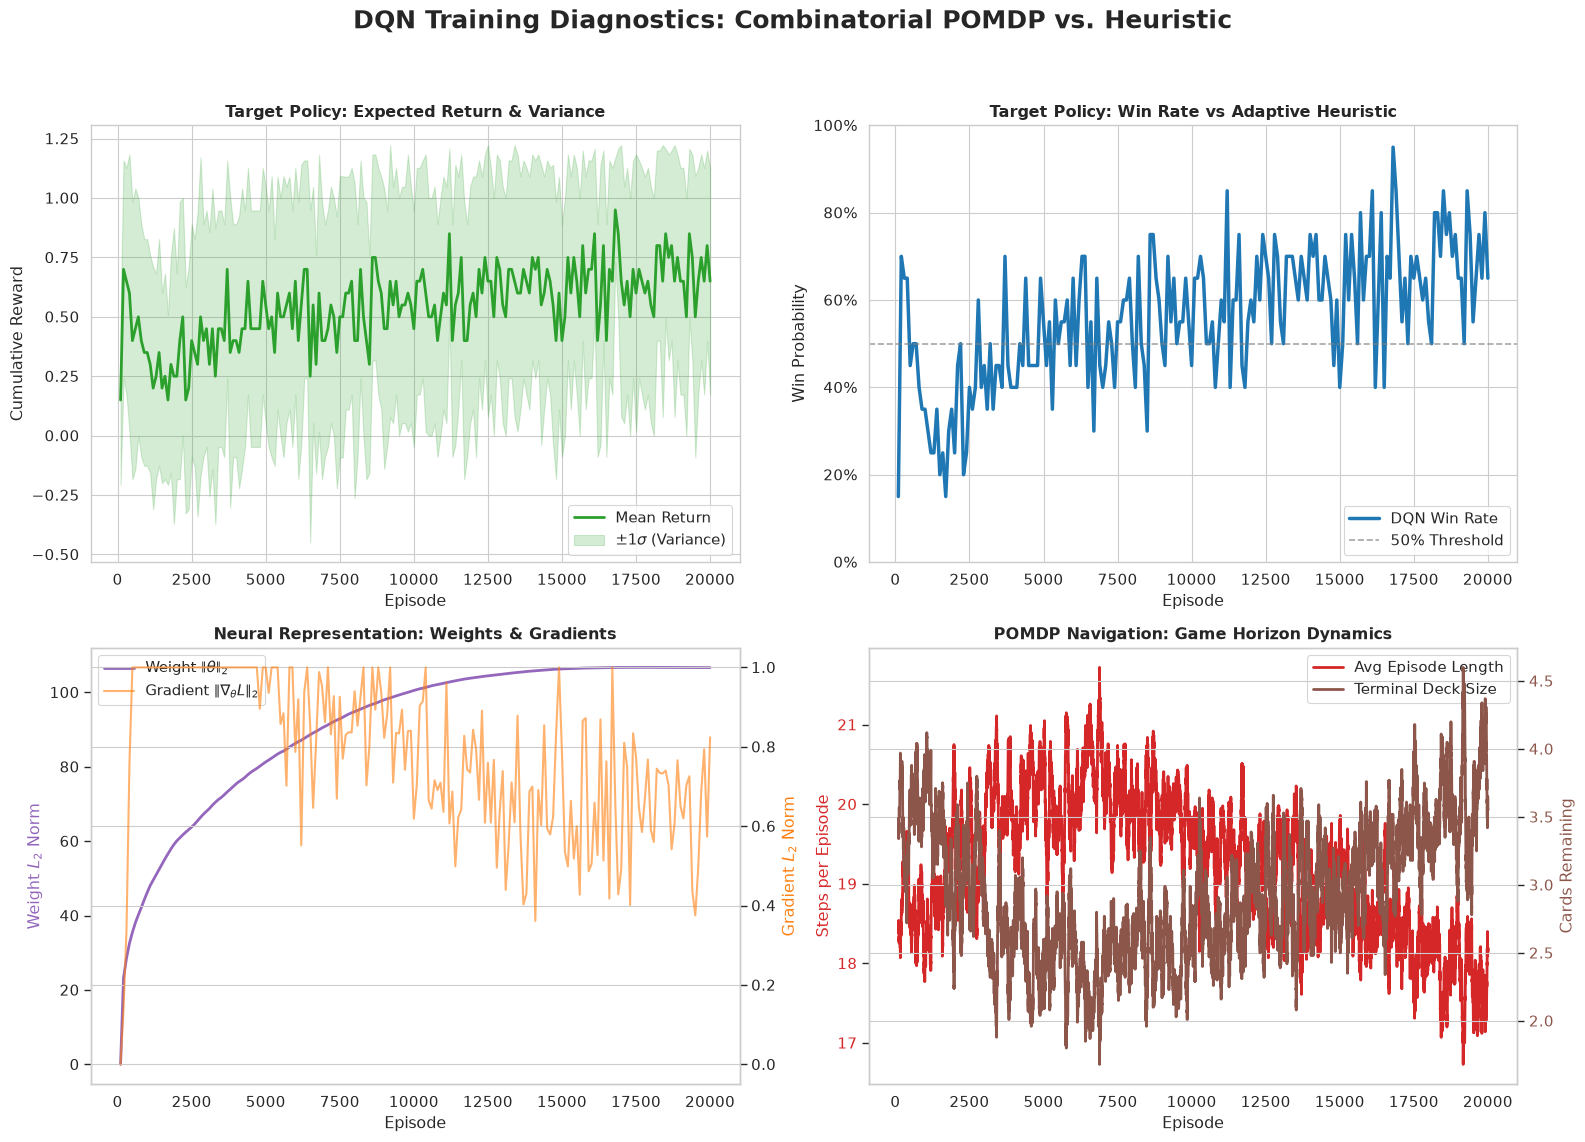

In [ ]:
# Optimal Configuration (Full POMDP)
standard_features = ["self_stats", "opp_stats", "self_hand", "self_board", "opp_board", "history_opp", "history_self", "deck_stats_self"]

env_self_play = CardDuelsEnv(
    card_pool=CARD_POOL, 
    deck_list_p1=DECK,
    deck_list_p2=DECK,
    max_hand=MAX_HAND,
    max_board=MAX_BOARD,
    max_hp=MAX_HP,
    mana_limit=MANA_LIMIT,
    total_unique_cards=len(CARD_POOL),
    obs_features=standard_features
)

# Instantiate a Fresh Agent
agent_self_play = DQNAgent(
    observation_space=env_self_play.observation_space,
    action_space=env_self_play.action_space,
    total_episodes=NUM_EPISODES,
    lr_start=1e-4,
    lr_min=LEARNING_RATE_MIN,
    gamma=GAMMA,
    epsilon_start=0.5,
    epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY,
    buffer_capacity=BUFFER_CAPACITY,
    batch_size=BATCH_SIZE,
    min_buffer_size=MIN_BUFFER_SIZE,
    target_sync_every=TARGET_SYNC_EVERY
)

# Load the Pre-Trained Feature Extractor and Q-Head allowing the agent to skip the random-initialization phase.
best_checkpoint_dir = "./checkpoints/heuristic_ablation/full_pomdp"
load_latest_checkpoint(agent_self_play, save_dir=best_checkpoint_dir)

# Define the Stationary Evaluation Benchmark
# The Self-Play agent is evaluated against the Heuristic.
eval_benchmark = HeuristicOpponent(
    max_hp=MAX_HP, 
    max_hand=MAX_HAND, 
    max_board=MAX_BOARD, 
    temperature=0.01
)

# Self-Play Optimization Loop
print("\n--- Initiating Shared-Weight Self-Play Fine-Tuning ---")
self_play_history = train_self_play(
    agent=agent_self_play,
    env=env_self_play,
    evaluation_benchmark_agent=eval_benchmark,
    episodes=NUM_EPISODES,
    max_steps=MAX_STEPS,
    train_freq=TRAIN_FREQUENCY,
    log_every=LOG_EVERY,
    save_dir="./checkpoints/selfplay/",
    seed=SEED
)


plot_training_diagnostics(self_play_history, save_dir="./plots/selfplay_diagnostics.png")